In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
# Loading Topsoil and Subsoil analysis results as excel files
Topdf = pd.read_excel('TopSoil_Compiled EDXFR Results_Orginal.xlsx') # Topsoil profile dataset
Subdf = pd.read_excel('SubSoil_Compiled EDXFR Results_Orginal.xlsx') # Subsoil profile dataset

### merging the two dataset

In [3]:
# Adding a column called layer to both dataset for identification of soil profile
Topdf['layer'] = 'Top_soil'
Subdf['layer'] = 'Sub_soil'

# Joining them
df_master = pd.concat([Topdf, Subdf], ignore_index=True)
pca_df = pd.DataFrame()
pca_df[['As','Cd','Pb','Zn','Cu','Fe','layer']] = df_master[['As (mg/kg)','Cd (mg/kg)','Pb (mg/kg)', 'Zn (mg/kg)','Cu (mg/kg)','Fe (mg/kg)','layer']]
                                                                                                             

### PCA Analsis
Because PTEs exhibited substantially different concentration ranges, the variables were standardized prior to distance–decay analysis using the StandardScaler(). This allowed comparison of the relative strength of spatial attenuation patterns among elements independent of their original concentration magnitudes.

Explained variance ratio: [0.42915999 0.21980066]
Total variance explained: 0.6489606527466578

Top contributors to PC1:
Pb    0.563319
Zn    0.551510
Cu    0.496030
Cd    0.272118
Fe    0.178316
Name: PC1, dtype: float64

Top contributors to PC2:
As    0.745333
Fe    0.557108
Pb    0.242372
Cu    0.234762
Zn    0.116852
Name: PC2, dtype: float64


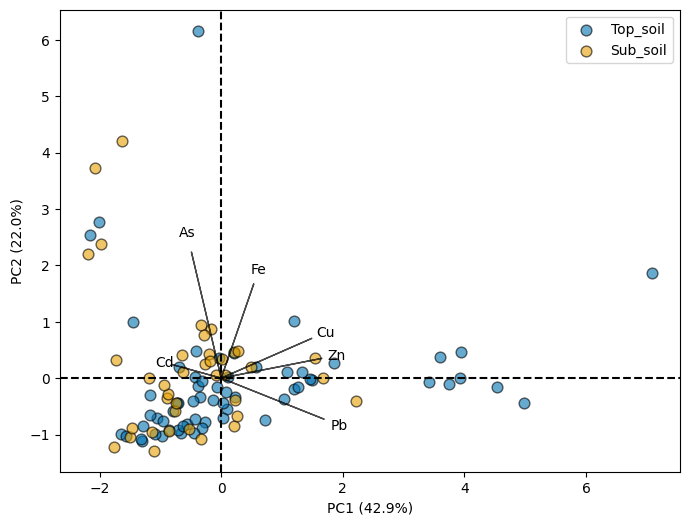

In [4]:
# Saving labels first 
labels = pca_df['layer']

# Drop non-numeric columns except label
X = pca_df.drop(columns=['layer'])

# 1. Scale data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

# 2. Apply PCA
pca = PCA(n_components=2)
components = pca.fit_transform(scaled_data)

# Convert to DataFrame
pca_df = pd.DataFrame(components, columns=['PC1', 'PC2'])
pca_df['layer'] = labels.values

# 3. Explain variance
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", sum(pca.explained_variance_ratio_))

# 4. Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=X.columns
)

print("\nTop contributors to PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head())

print("\nTop contributors to PC2:")
print(loadings['PC2'].abs().sort_values(ascending=False).head())

# 5. BIPLOT (with arrows)

plt.figure(figsize=(8,6))

colors = {
    'Top_soil': '#0072B2',   
    'Sub_soil': '#E69F00'    
}

# Plot points
for label in pca_df['layer'].unique():
    subset = pca_df[pca_df['layer'] == label]
    plt.scatter(subset['PC1'], subset['PC2'],
                label=label,
                color=colors.get(label, 'black'),  # fallback color
                edgecolor='black',
                s=60,              # point size
                alpha=0.6)

# Scale arrows for visibility
arrow_scale = 3

# Plot arrows (loadings)
for i, var in enumerate(X.columns):
    plt.arrow(0, 0,
              loadings.iloc[i, 0]*arrow_scale,
              loadings.iloc[i, 1]*arrow_scale,
              color='black', alpha=0.7)

    plt.text(loadings.iloc[i, 0]*arrow_scale*1.15,
             loadings.iloc[i, 1]*arrow_scale*1.15,
             var,
             color='black', ha='center', va='center')

plt.axhline(0, linestyle='--', color='black')
plt.axvline(0, linestyle='--', color='black')

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
###plt.title("PCA Biplot (Scores + Loadings)")
plt.legend()
plt.grid(False)
plt.savefig("PCA_ts.png", dpi=300, bbox_inches='tight')
plt.savefig("PCA_ts.pdf", dpi=300, bbox_inches='tight')
plt.show()

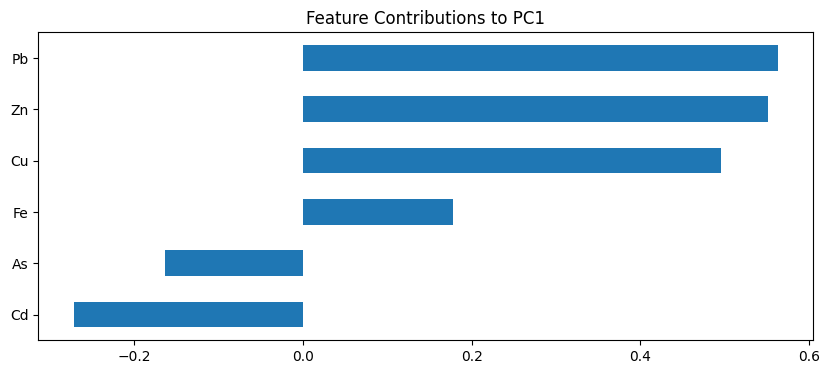

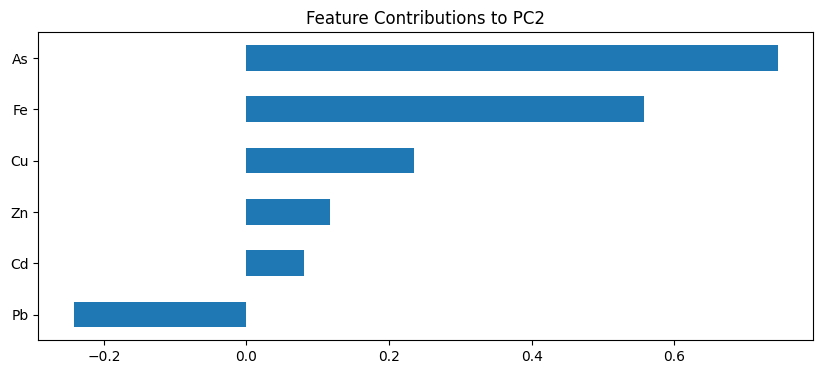

In [5]:
# 6. Optional: Feature contribution bar plots

plt.figure(figsize=(10,4))
loadings['PC1'].sort_values().plot(kind='barh')
plt.title("Feature Contributions to PC1")
plt.show()

plt.figure(figsize=(10,4))
loadings['PC2'].sort_values().plot(kind='barh')
plt.title("Feature Contributions to PC2")
plt.show()